In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2

In [31]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [32]:
type(x_train)

numpy.ndarray

In [33]:
x_train.dtype

dtype('uint8')

In [34]:
print('Training data shape   : ', x_train.shape)
print('Training labels shape : ', y_train.shape)
print('Testing data shape    : ', x_test.shape)
print('Testing labels shape  : ', y_test.shape)

Training data shape   :  (60000, 28, 28)
Training labels shape :  (60000,)
Testing data shape    :  (10000, 28, 28)
Testing labels shape  :  (10000,)


In [35]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

(-0.5, 27.5, 27.5, -0.5)

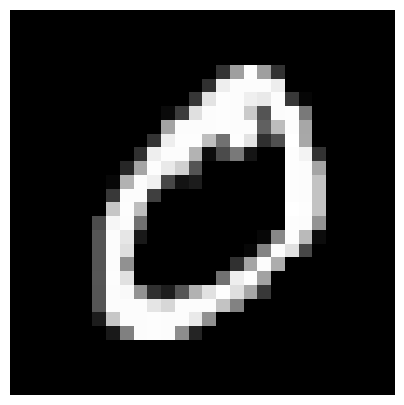

In [36]:
plt.figure(figsize = (5,5))
plt.imshow(x_train[1], cmap = 'gray')
plt.axis('off')

In [37]:
np.set_printoptions(linewidth = 200)
print(x_train[1])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253 159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 253 252 252  96 18

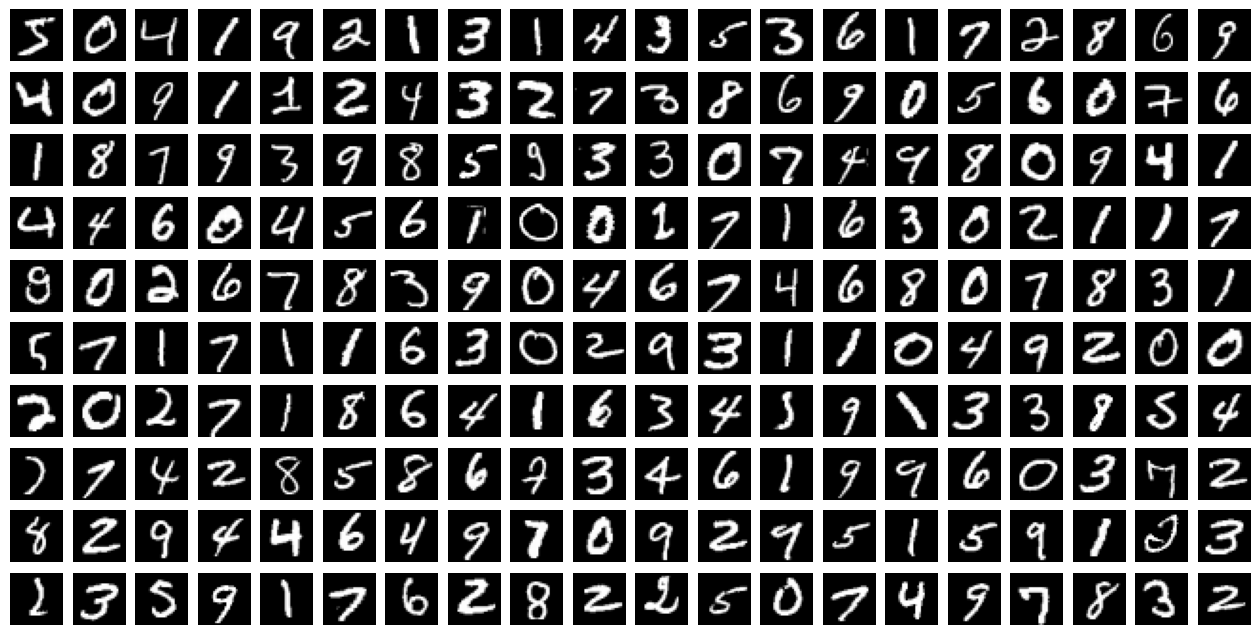

In [38]:
plt.figure(figsize = (16,8))
for i in range(200):
  plt.subplot(10,20,i+1)
  plt.imshow(x_train[i], cmap = 'gray')
  plt.axis('off')

---
---

In [39]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes = 10)
y_test  = to_categorical(y_test, num_classes = 10)

x_train = x_train.reshape(60000,28,28,1)
x_test  = x_test.reshape(10000,28,28,1)

In [40]:
print('Training data shape   : ', x_train.shape)
print('Training labels shape : ', y_train.shape)
print('Testing data shape    : ', x_test.shape)
print('Testing labels shape  : ', y_test.shape)

Training data shape   :  (60000, 28, 28, 1)
Training labels shape :  (60000, 10)
Testing data shape    :  (10000, 28, 28, 1)
Testing labels shape  :  (10000, 10)


## Augmentation

In [41]:
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    rotation_range = 0.1,
    shear_range = 0.1,
    # zoom_range = 0.1,
    # horizontal_flip = True,
    # vertical_flip = True
)

train_datagen.fit(x_train)
train_generator = train_datagen.flow(x_train, y_train, batch_size = 1000)

In [42]:
val_datagen = ImageDataGenerator(rescale = 1/255)
val_datagen.fit(x_test)
val_generator = val_datagen.flow(x_test, y_test)

## Steps to create and train a neural network
1. Create the architecture
2. Compile the model
3. Fit the model

In [44]:
# Creating the architecture
model = tf.keras.models.Sequential()

model.add(Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = (28,28,1)))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3,3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3,3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D())

model.add(Conv2D(256, (3,3), activation = 'relu', padding = 'same'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(100, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_26 (Conv2D)          (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_25 (MaxPooli  (None, 14, 14, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_27 (Conv2D)          (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_26 (MaxPooli  (None, 7, 7, 64)          0         
 ng2D)                                                           
                                                                 
 conv2d_28 (Conv2D)          (None, 7, 7, 128)         73856     
                                                                 
 max_pooling2d_27 (MaxPooli  (None, 3, 3, 128)       

18496

In [45]:
# Compile the model
model.compile(loss = 'categorical_crossentropy',
              optimizer  = Adam(learning_rate = 0.001),
              metrics = ['accuracy'])

In [46]:
history = model.fit(
          train_generator,
          validation_data = (val_generator),
          epochs = 50,
          verbose = 1)

Epoch 1/50
60/60 [==============================] - 22s 295ms/step - loss: 1.0136 - accuracy: 0.6747 - val_loss: 0.2816 - val_accuracy: 0.9122
Epoch 2/50
60/60 [==============================] - 17s 292ms/step - loss: 0.2607 - accuracy: 0.9205 - val_loss: 0.1432 - val_accuracy: 0.9535
Epoch 3/50
60/60 [==============================] - 17s 279ms/step - loss: 0.1701 - accuracy: 0.9470 - val_loss: 0.1123 - val_accuracy: 0.9645
Epoch 4/50
60/60 [==============================] - 18s 308ms/step - loss: 0.1281 - accuracy: 0.9613 - val_loss: 0.0869 - val_accuracy: 0.9706
Epoch 5/50
60/60 [==============================] - 17s 287ms/step - loss: 0.1096 - accuracy: 0.9663 - val_loss: 0.0665 - val_accuracy: 0.9777
Epoch 6/50
60/60 [==============================] - 17s 290ms/step - loss: 0.0910 - accuracy: 0.9717 - val_loss: 0.0592 - val_accuracy: 0.9800
Epoch 7/50
60/60 [==============================] - 17s 283ms/step - loss: 0.0758 - accuracy: 0.9771 - val_loss: 0.0789 - val_accuracy: 0.9734

In [47]:
acc_train = history.history['accuracy']
acc_val   = history.history['val_accuracy']

loss_train = history.history['loss']
loss_val   = history.history['val_loss']

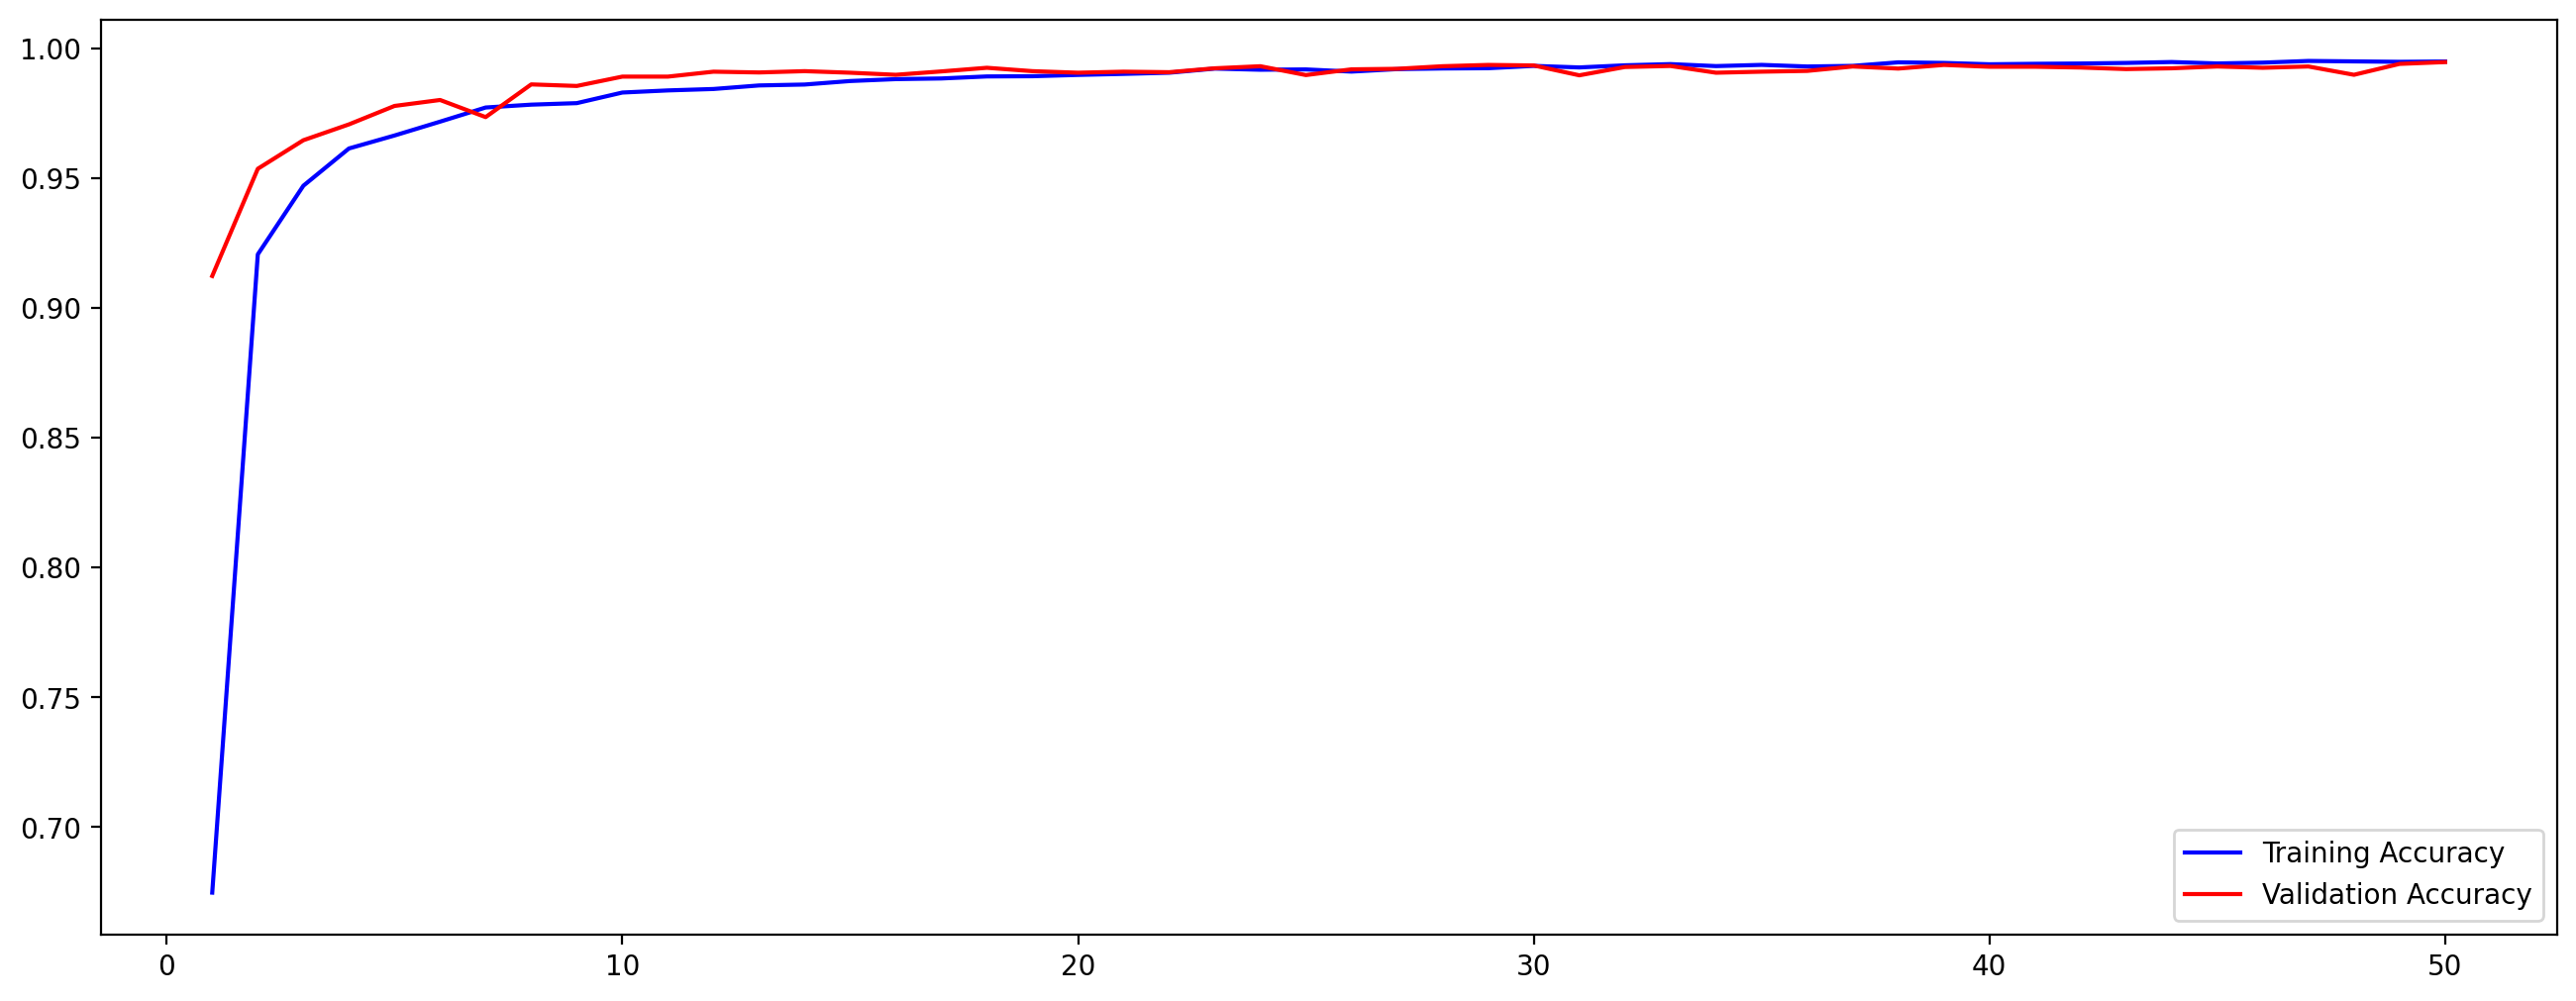

In [48]:
num_epochs = range(1,51)

plt.figure(figsize  =(16,6), dpi = 200)
plt.plot(num_epochs, acc_train, c = 'blue', label = 'Training Accuracy')
plt.plot(num_epochs, acc_val, c = 'red', label = 'Validation Accuracy')
plt.legend()
plt.show()

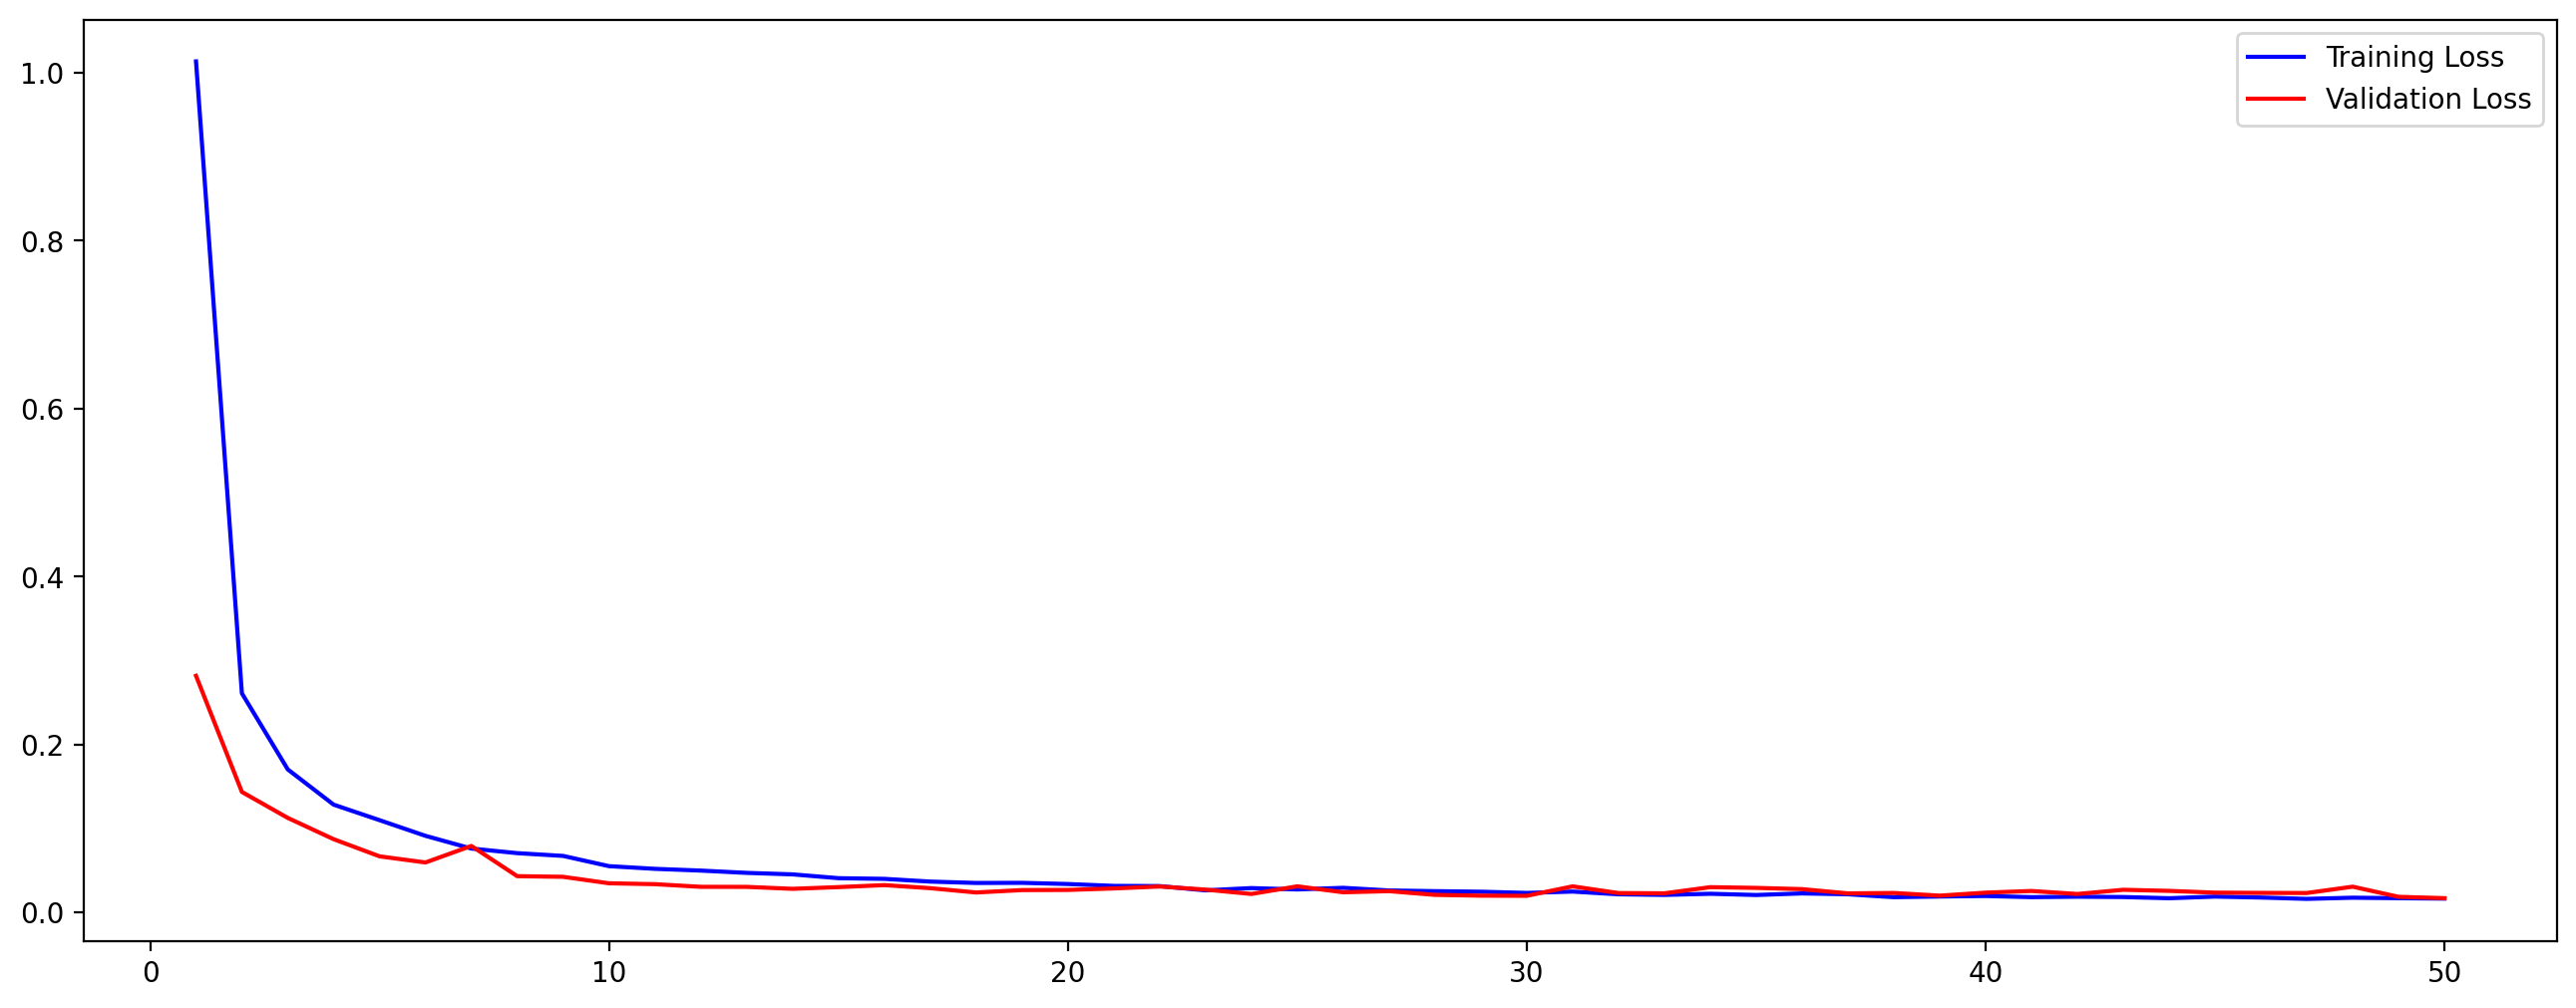

In [49]:
plt.figure(figsize  =(16,6), dpi = 200)
plt.plot(num_epochs, loss_train, c = 'blue', label = 'Training Loss')
plt.plot(num_epochs, loss_val, c = 'red', label = 'Validation Loss')
plt.legend()
plt.show()

In [50]:
model.predict(x_train[1:2])

1/1 [==============================] - 0s 343ms/step


array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [51]:
model.predict(x_train[0:10])

1/1 [==============================] - 0s 176ms/step


array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [64]:
np.argmax(model.predict(x_train[:1]))

1/1 [==============================] - 0s 17ms/step


5

In [63]:
x_train[:1].shape

(1, 28, 28, 1)

In [53]:
np.argmax(model.predict(x_train[:10]), axis = 1)

1/1 [==============================] - 0s 18ms/step


array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

In [54]:
def predict_digit(x):
  preds = model.predict(x)
  preds = np.argmax(preds, axis = 1)

  for pred in preds:
    print('The given image is a : ', pred)

In [55]:
predict_digit(x_train[0:10])

1/1 [==============================] - 0s 17ms/step
The given image is a :  5
The given image is a :  0
The given image is a :  4
The given image is a :  1
The given image is a :  9
The given image is a :  2
The given image is a :  1
The given image is a :  3
The given image is a :  1
The given image is a :  4


In [65]:
def read_image(path):
  image = cv2.imread(path)
  image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  image = cv2.resize(image, (28,28))
  image = image.reshape((1, 28, 28, 1))
  return image

In [66]:
path = '/content/digit7.png'
img = read_image(path)
print(img.shape)
predict_digit(img)

(1, 28, 28, 1)
1/1 [==============================] - 0s 20ms/step
The given image is a :  7


In [67]:
predict_digit(img)

1/1 [==============================] - 0s 17ms/step
The given image is a :  7
